# **1. Dataset Description**

The dataset provided contains a comprehensive collection of used car listings, which we will use to build a regression model to predict vehicle market prices. Understanding the structure and composition of this data is the foundational step in our analysis and feature engineering process.

| Column | Description |
| :--- | :--- |
| **Price** | **(Target)** The market value of the car in local currency. |
| **name** | The brand and model name of the vehicle. |
| **company** | The manufacturer or brand of the vehicle. |
| **year** | The manufacturing year of the vehicle. |
| **kms_driven** | The total distance the vehicle has traveled in kilometers. |
| **fuel_type** | The type of fuel used (e.g., Petrol, Diesel, CNG). |

### Dataset Overview
*   **Total Listings:** 811 vehicle records (post-outlier filtering).
*   **Purpose:** Development of a price prediction model to assist in valuation and market analysis.
*   **Attributes:** The dataset encompasses key technical and operational specifications including engine fuel type, mileage, and vehicle age, allowing for a multifaceted approach to depreciation modeling.

## Live Demo
[![Streamlit App](https://static.streamlit.io/badges/streamlit_badge_black_white.svg)](https://donna7-car-price-predictor.streamlit.app)

# **1. Import Libraries**

In [326]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


# **2. Import dataset**

In [327]:
car=pd.read_csv('quikr_car.csv')

In [328]:
car.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [329]:
car.shape

(892, 6)

In [330]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


##### Creating backup copy

In [331]:
backup=car.copy()

In [332]:
car['year'].unique()

array(['2007', '2006', '2018', '2014', '2015', '2012', '2013', '2016',
       '2010', '2017', '2008', '2011', '2019', '2009', '2005', '2000',
       '...', '150k', 'TOUR', '2003', 'r 15', '2004', 'Zest', '/-Rs',
       'sale', '1995', 'ara)', '2002', 'SELL', '2001', 'tion', 'odel',
       '2 bs', 'arry', 'Eon', 'o...', 'ture', 'emi', 'car', 'able', 'no.',
       'd...', 'SALE', 'digo', 'sell', 'd Ex', 'n...', 'e...', 'D...',
       ', Ac', 'go .', 'k...', 'o c4', 'zire', 'cent', 'Sumo', 'cab',
       't xe', 'EV2', 'r...', 'zest'], dtype=object)

In [333]:
car['Price'].unique()

array(['80,000', '4,25,000', 'Ask For Price', '3,25,000', '5,75,000',
       '1,75,000', '1,90,000', '8,30,000', '2,50,000', '1,82,000',
       '3,15,000', '4,15,000', '3,20,000', '10,00,000', '5,00,000',
       '3,50,000', '1,60,000', '3,10,000', '75,000', '1,00,000',
       '2,90,000', '95,000', '1,80,000', '3,85,000', '1,05,000',
       '6,50,000', '6,89,999', '4,48,000', '5,49,000', '5,01,000',
       '4,89,999', '2,80,000', '3,49,999', '2,84,999', '3,45,000',
       '4,99,999', '2,35,000', '2,49,999', '14,75,000', '3,95,000',
       '2,20,000', '1,70,000', '85,000', '2,00,000', '5,70,000',
       '1,10,000', '4,48,999', '18,91,111', '1,59,500', '3,44,999',
       '4,49,999', '8,65,000', '6,99,000', '3,75,000', '2,24,999',
       '12,00,000', '1,95,000', '3,51,000', '2,40,000', '90,000',
       '1,55,000', '6,00,000', '1,89,500', '2,10,000', '3,90,000',
       '1,35,000', '16,00,000', '7,01,000', '2,65,000', '5,25,000',
       '3,72,000', '6,35,000', '5,50,000', '4,85,000', '3,29,5

In [334]:
car['kms_driven'].unique()

array(['45,000 kms', '40 kms', '22,000 kms', '28,000 kms', '36,000 kms',
       '59,000 kms', '41,000 kms', '25,000 kms', '24,530 kms',
       '60,000 kms', '30,000 kms', '32,000 kms', '48,660 kms',
       '4,000 kms', '16,934 kms', '43,000 kms', '35,550 kms',
       '39,522 kms', '39,000 kms', '55,000 kms', '72,000 kms',
       '15,975 kms', '70,000 kms', '23,452 kms', '35,522 kms',
       '48,508 kms', '15,487 kms', '82,000 kms', '20,000 kms',
       '68,000 kms', '38,000 kms', '27,000 kms', '33,000 kms',
       '46,000 kms', '16,000 kms', '47,000 kms', '35,000 kms',
       '30,874 kms', '15,000 kms', '29,685 kms', '1,30,000 kms',
       '19,000 kms', nan, '54,000 kms', '13,000 kms', '38,200 kms',
       '50,000 kms', '13,500 kms', '3,600 kms', '45,863 kms',
       '60,500 kms', '12,500 kms', '18,000 kms', '13,349 kms',
       '29,000 kms', '44,000 kms', '42,000 kms', '14,000 kms',
       '49,000 kms', '36,200 kms', '51,000 kms', '1,04,000 kms',
       '33,333 kms', '33,600 kms', '5,

In [335]:
car['fuel_type']. unique()

array(['Petrol', 'Diesel', nan, 'LPG'], dtype=object)

## Quality
- `year` has many non-year values
- convert `year` type from object to int
- `Price` has 'ask for price'
- convert `Price` type from object to int
- `kms_driven` has 'kms' string with the integers
- `kms_driven` has NaN values
- `fuel_type` has NaN values
- keep the first 3 words only from the `name`

# **3. Data Cleaning**

#### `year` has many non-year values

In [336]:
car=car[car['year'].str.isnumeric()]

#### `year` is an object, Change to integer

In [337]:
car['year']=car['year'].astype(int)

#### `Price` has 'Ask for Price'

In [338]:
car=car[car['Price']!='Ask For Price']

#### `Price` has commas in its prices and is an object

In [339]:
car['Price']=car['Price'].str.replace(',','').astype(int)

####  `kms_driven` has object values with 'kms' at last as a unit.

In [340]:
car['kms_driven']=car['kms_driven'].str.split().str.get(0).str.replace(',','')

#### It also has nan values and two rows have 'Petrol' in them

In [341]:
car=car[car['kms_driven'].str.isnumeric()]

In [342]:
car['kms_driven']=car['kms_driven'].astype(int)

#### `fuel_type` has nan values

In [343]:
car=car[~car['fuel_type'].isna()]

In [344]:
car.shape

(816, 6)

### `name` and `company` had spammed data...but with the previous cleaning, those rows got removed.

#### `company` does not need any cleaning now. Changing car `names` by Keeping only the first three words

In [345]:
car['name']=car['name'].str.split().str.slice(start=0,stop=3).str.join(' ')

#### Resetting the index of the final cleaned data

In [346]:
car=car.reset_index(drop=True)

## Cleaned Data

In [347]:
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
811,Maruti Suzuki Ritz,Maruti,2011,270000,50000,Petrol
812,Tata Indica V2,Tata,2009,110000,30000,Diesel
813,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
814,Tata Zest XM,Tata,2018,260000,27000,Diesel


In [348]:
car.to_csv('Cleaned_Car_data.csv')

In [349]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    int64 
 3   Price       816 non-null    int64 
 4   kms_driven  816 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 38.4+ KB


In [350]:
car.describe(include='all')

,name,company,year,Price,kms_driven,fuel_type
count,816,816,816.000000,8.160000e+02,816.000000,816
unique,254,25,NaN,NaN,NaN,3
top,Maruti Suzuki Swift,Maruti,NaN,NaN,NaN,Petrol
freq,51,221,NaN,NaN,NaN,428
mean,NaN,NaN,2012.444853,4.117176e+05,46275.531863,NaN
std,NaN,NaN,4.002992,4.751844e+05,34297.428044,NaN
min,NaN,NaN,1995.000000,3.000000e+04,0.000000,NaN
25%,NaN,NaN,2010.000000,1.750000e+05,27000.000000,NaN
50%,NaN,NaN,2013.000000,2.999990e+05,41000.000000,NaN
75%,NaN,NaN,2015.000000,4.912500e+05,56818.500000,NaN


it is obvious that the max in `Price` is an outlier as it is e6 not even e5

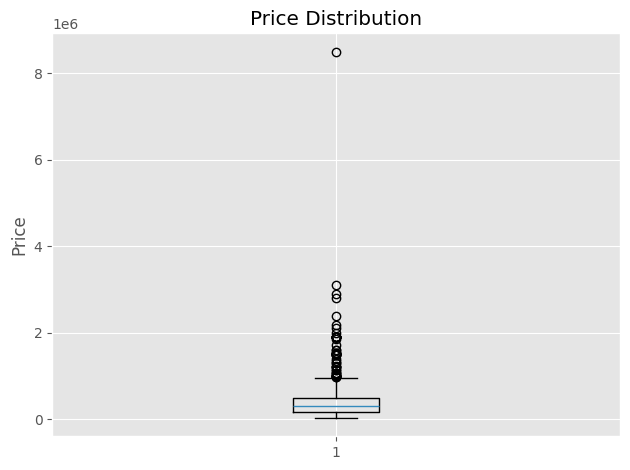

In [351]:
plt.boxplot(car['Price'])
plt.title('Price Distribution')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

In [352]:
car=car[car['Price']<6000000]

We filter the dataset by `Price` to remove extreme outliers, ensuring the model focuses on typical market pricing and avoids being skewed by exceptionally expensive luxury vehicles.


In [353]:
car.describe()

,year,Price,kms_driven
count,815.000000,8.150000e+02,815.000000
mean,2012.442945,4.017933e+05,46277.096933
std,4.005079,3.815888e+05,34318.459638
min,1995.000000,3.000000e+04,0.000000
25%,2010.000000,1.750000e+05,27000.000000
50%,2013.000000,2.999990e+05,41000.000000
75%,2015.000000,4.900000e+05,56879.000000
max,2019.000000,3.100000e+06,400000.000000


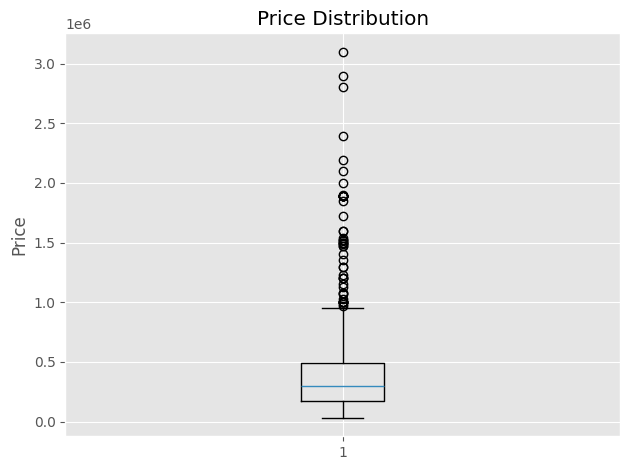

In [354]:
plt.boxplot(car['Price'])
plt.title('Price Distribution')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# **4. Exploratory Data Analysis (EDA)**

### 4.1. Statistical Summary & Correlation

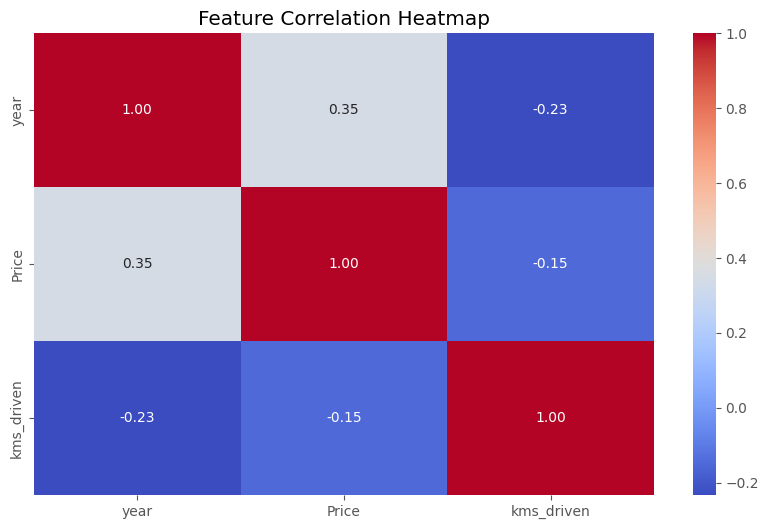

In [355]:
#  Correlation Heatmap
plt.figure(figsize=(10, 6))
# Use .select_dtypes(include=['number']) to filter out string columns
sns.heatmap(car.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

The heatmap shows a moderate positive correlation between `year` and `Price`, indicating that newer cars generally have higher prices, while there is a weak negative correlation between `kms_driven` and `Price`, suggesting that higher mileage is associated with lower market value.

### 4.2. Checking relationship of Company with Price

In [356]:
car['company'].unique()

array(['Hyundai', 'Mahindra', 'Ford', 'Maruti', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'Tata', 'Volkswagen',
       'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat', 'Force',
       'Mercedes', 'Land', 'Jaguar', 'Jeep', 'Volvo'], dtype=object)

/tmp/ipykernel_1201/486881296.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')


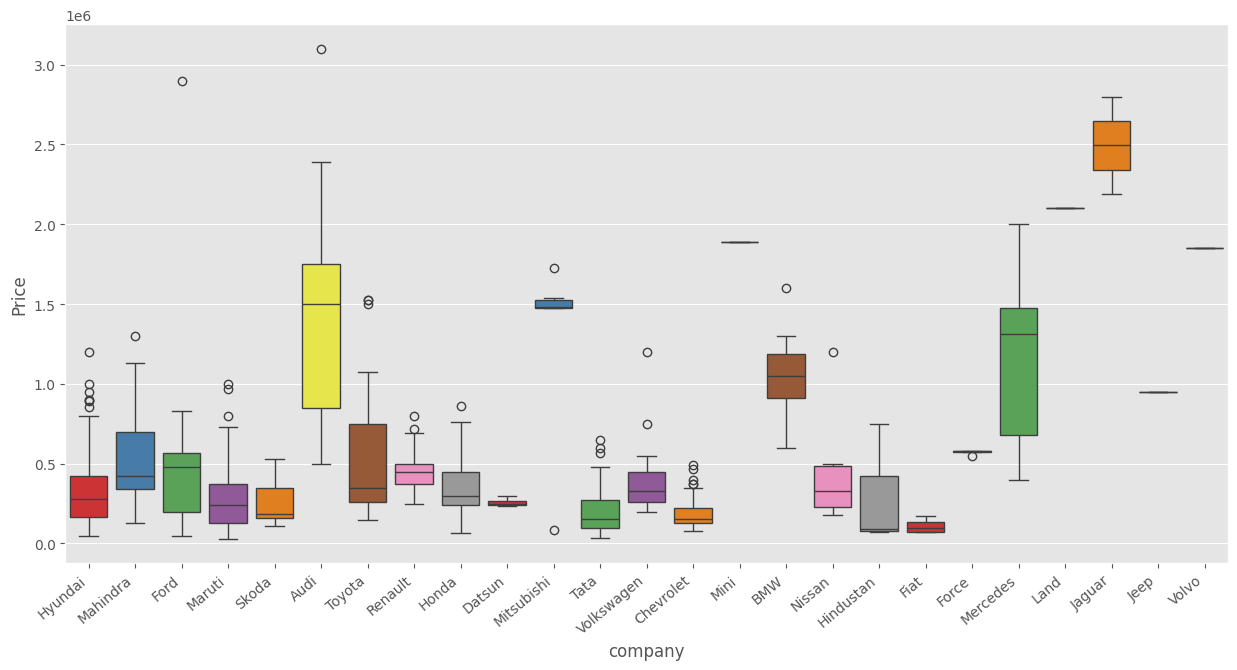

In [357]:
plt.subplots(figsize=(15,7))
ax=sns.boxplot(x='company',y='Price',data=car, hue='company', palette='Set1')
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()

### 4.3. Checking relationship of Year with Price

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 13.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 13.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 6.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 10.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 7.7% of the points cannot be placed

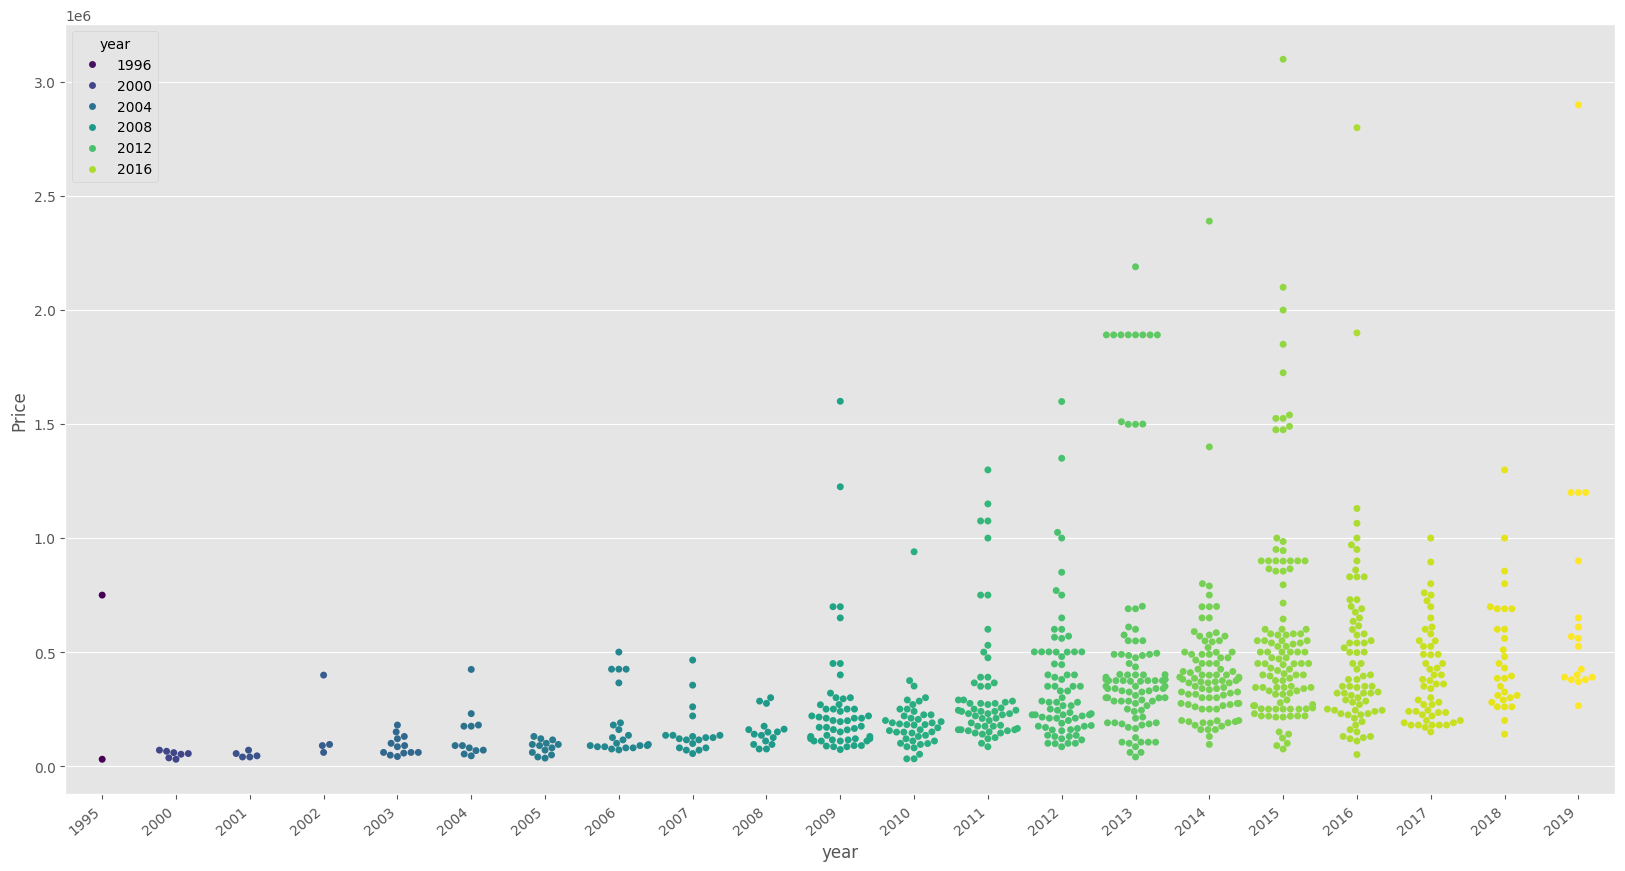

In [358]:
plt.subplots(figsize=(20,10))
ax=sns.swarmplot(x='year',y='Price',data=car, hue='year', palette='viridis')
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()

The swarmplot demonstrates that more recent model years generally exhibit a wider range of price points and higher maximum values, reflecting the expected trend of depreciation where older vehicles are concentrated in lower price brackets.

### 4.4. Checking relationship of kms_driven with Price

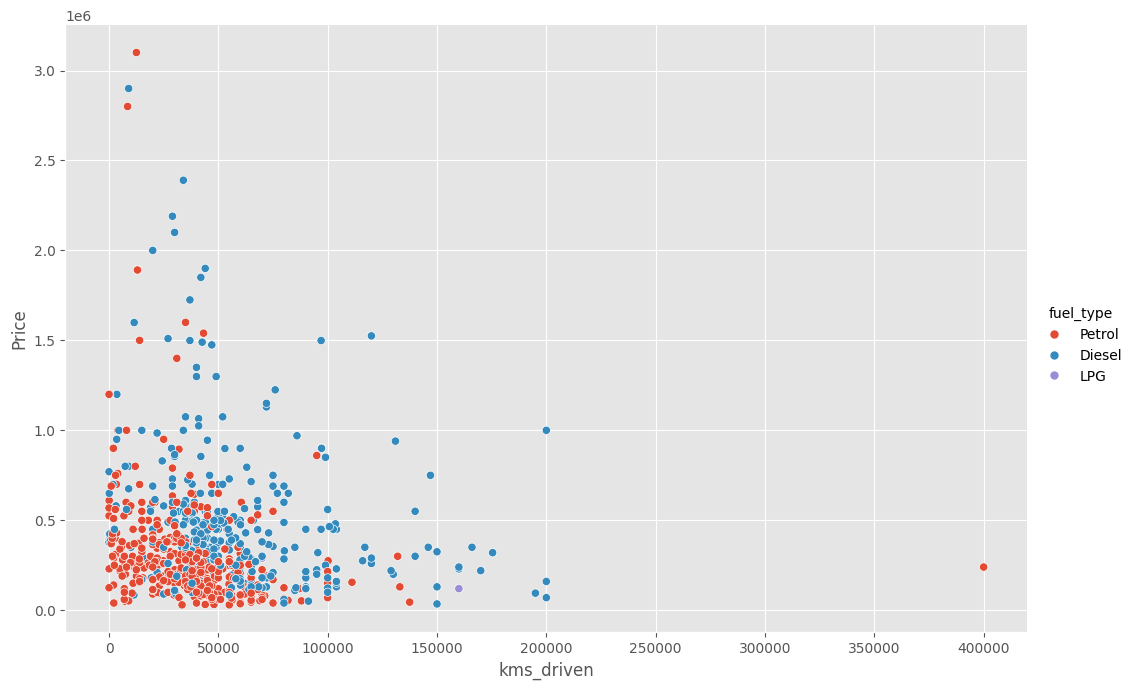

In [359]:
sns.relplot(x='kms_driven',y='Price',data=car, hue='fuel_type',height=7,aspect=1.5)

The scatter plot reveals an inverse relationship between `kms_driven` and `Price`, showing that as vehicle mileage increases, market value generally decreases, with Diesel vehicles frequently occupying higher price brackets across various mileage levels compared to Petrol counterparts.

### 4.5 Checking relationship of Fuel Type with Price

<Axes: xlabel='fuel_type', ylabel='Price'>

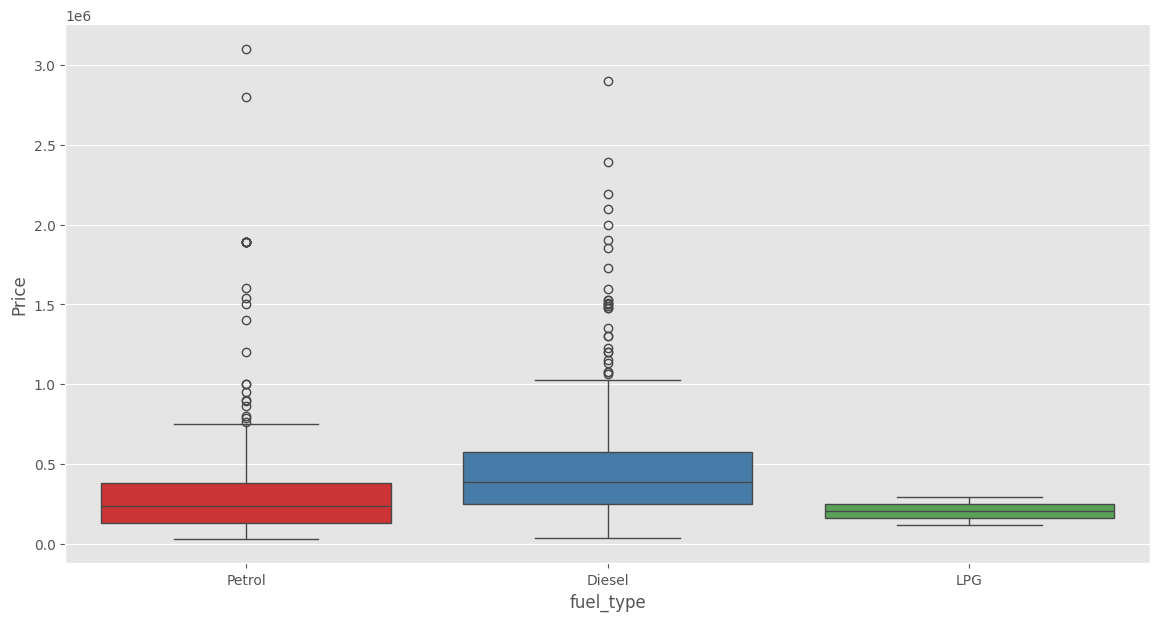

In [360]:
plt.subplots(figsize=(14,7))
sns.boxplot(x='fuel_type',y='Price',data=car, hue='fuel_type', palette='Set1')

The boxplot illustrates that Diesel vehicles generally command higher median prices and exhibit a broader price range compared to Petrol vehicles, while LPG vehicles maintain a consistently lower and narrower price distribution.

### 4.6. Relationship of Price with FuelType, Year and Company mixed

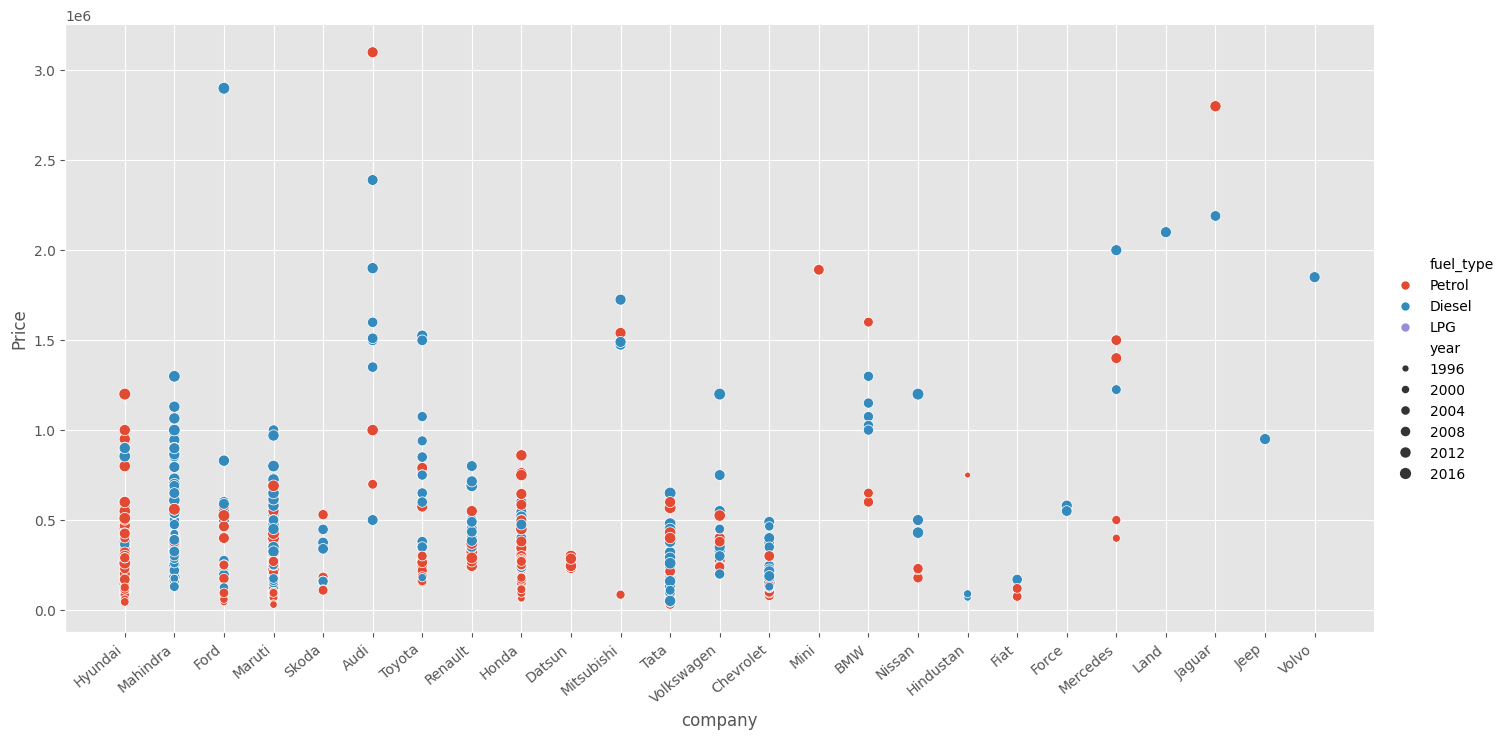

In [361]:
ax=sns.relplot(x='company',y='Price',data=car,hue='fuel_type',size='year',height=7,aspect=2)
ax.set_xticklabels(rotation=40,ha='right')

# **5. Data Preprocessing**

## **5.1. Declare feature vector and target variable**

In [362]:
X=car[['name','company','year','kms_driven','fuel_type']]
y=car['Price']

In [363]:
X

,name,company,year,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,36000,Diesel
4,Ford Figo,Ford,2012,41000,Diesel
...,...,...,...,...,...
811,Maruti Suzuki Ritz,Maruti,2011,50000,Petrol
812,Tata Indica V2,Tata,2009,30000,Diesel
813,Toyota Corolla Altis,Toyota,2009,132000,Petrol
814,Tata Zest XM,Tata,2018,27000,Diesel


In [364]:
y.shape

(815,)

## 5.2. Data Splitting: Training and Testing Sets

In [365]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

## 5.3. Encoding Categorical Data with OneHotEncoder

In [366]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

#### Creating an OneHotEncoder object to contain all the possible categories

In [367]:
ohe=OneHotEncoder()
ohe.fit(X[['name','company','fuel_type']])

OneHotEncoder()

#### Creating a column transformer to transform categorical columns

In [368]:
column_trans=make_column_transformer((OneHotEncoder(categories=ohe.categories_),['name','company','fuel_type']),
                                    remainder='passthrough')

# **6. Model Building**

In [369]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_absolute_error , root_mean_squared_error

#### Linear Regression Model

In [370]:
lr=LinearRegression()

#### Making a pipeline

In [371]:
from sklearn.pipeline import make_pipeline

In [372]:
pipe=make_pipeline(column_trans,lr)

#### Fitting the  model

In [373]:
pipe.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['Audi A3 Cabriolet', 'Audi A4 1.8', 'Audi A4 2.0', 'Audi A6 2.0',
       'Audi A8', 'Audi Q3 2.0', 'Audi Q5 2.0', 'Audi Q7', 'BMW 3 Series',
       'BMW 5 Series', 'BMW 7 Series', 'BMW X1', 'BMW X1 sDrive20d',
       'BMW X1 xDrive20d', 'Chevrolet Beat', 'Chevrolet Beat...
                                                                            array(['Audi', 'BMW', 'Chevrolet', 'Datsun', 'Fiat', 'Force', 'Ford',
       'Hindustan', 'Honda', 'Hyundai', 'Jaguar', 'Jeep', 'Land',
       'Mahindra', 'Maruti', 'Mercedes', 'Mini', 'Mitsubishi', 'Nissan',
       'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo'],
      dtype=object),
                                                                            array(['Diesel', 'LPG', 'Petrol'], dtype=object)]),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('linearregression', LinearRegression())])

In [374]:
y_pred=pipe.predict(X_test)

#### Checking Evaulation metrics

In [375]:
# Calculate metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

# Print results with dollar sign formatting
print(f"R2 Score: {r2:.3f}")
print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

R2 Score: 0.602
MAE: $132,097.89
RMSE: $209,307.88


#### Finding the model with a random state of TrainTestSplit where the model was found to give almost 0.90 as r2_score

In [376]:
scores=[]
for i in range(1000):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=i)
    lr=LinearRegression()
    pipe=make_pipeline(column_trans,lr)
    pipe.fit(X_train,y_train)
    y_pred=pipe.predict(X_test)
    scores.append(r2_score(y_test,y_pred))

In [377]:
np.argmax(scores)

np.int64(302)

In [378]:
scores[np.argmax(scores)]

0.8991157554877304

#### The best model is found at a certain random state

In [379]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=np.argmax(scores))
lr=LinearRegression()
pipe=make_pipeline(column_trans,lr)
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(root_mean_squared_error(y_test,y_pred))

0.8991157554877304
98320.64632381072
139169.96557674668


# **7. K-Fold Cross-Validation**

In [380]:
from sklearn.model_selection import KFold, cross_val_score

# 1. Use the full original X and y
# The pipeline handles the transformation internally for every fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Use your existing pipeline
cv_scores = cross_val_score(pipe, X, y, cv=kf, scoring='r2')

print("--- K-Fold Cross-Validation Results ---")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i} R2 Score: {score:.4f}")

print("-" * 30)
print(f"Mean CV R2 Score: {cv_scores.mean():.4f}")

--- K-Fold Cross-Validation Results ---
Fold 1 R2 Score: 0.5733
Fold 2 R2 Score: 0.7055
Fold 3 R2 Score: 0.4720
Fold 4 R2 Score: 0.7163
Fold 5 R2 Score: 0.7289
------------------------------
Mean CV R2 Score: 0.6392


The results of the 5-fold cross-validation reveal a mean $R^2$ score of approximately **0.64**, though the significant variance between the lowest and highest fold scores suggests that the model's performance is sensitive to how the data is split.

### Testing the model on an example

In [381]:
pipe.predict(pd.DataFrame(columns=X_test.columns,data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

array([456670.3272301])

# **8. Deployment Preperation**

In [382]:
pickle.dump(pipe,open('LinearRegressionModel.pkl','wb'))

### Inspecting Learned Categories

In [384]:
pipe.steps[0][1].transformers[0][1].categories[0]

array(['Audi A3 Cabriolet', 'Audi A4 1.8', 'Audi A4 2.0', 'Audi A6 2.0',
       'Audi A8', 'Audi Q3 2.0', 'Audi Q5 2.0', 'Audi Q7', 'BMW 3 Series',
       'BMW 5 Series', 'BMW 7 Series', 'BMW X1', 'BMW X1 sDrive20d',
       'BMW X1 xDrive20d', 'Chevrolet Beat', 'Chevrolet Beat Diesel',
       'Chevrolet Beat LS', 'Chevrolet Beat LT', 'Chevrolet Beat PS',
       'Chevrolet Cruze LTZ', 'Chevrolet Enjoy', 'Chevrolet Enjoy 1.4',
       'Chevrolet Sail 1.2', 'Chevrolet Sail UVA', 'Chevrolet Spark',
       'Chevrolet Spark 1.0', 'Chevrolet Spark LS', 'Chevrolet Spark LT',
       'Chevrolet Tavera LS', 'Chevrolet Tavera Neo', 'Datsun GO T',
       'Datsun Go Plus', 'Datsun Redi GO', 'Fiat Linea Emotion',
       'Fiat Petra ELX', 'Fiat Punto Emotion', 'Force Motors Force',
       'Force Motors One', 'Ford EcoSport', 'Ford EcoSport Ambiente',
       'Ford EcoSport Titanium', 'Ford EcoSport Trend',
       'Ford Endeavor 4x4', 'Ford Fiesta', 'Ford Fiesta SXi', 'Ford Figo',
       'Ford Figo Diese